# 도형의 이동 (변환)

좌표평면에서 자주 쓰는 변환:

| 변환 | 점 $(x,y)$ → |
|------|----------------|
| 평행이동 $(p,q)$ | $(x+p,\; y+q)$ |
| $x$축 대칭 | $(x,\; -y)$ |
| $y$축 대칭 | $(-x,\; y)$ |
| 원점 대칭 | $(-x,\; -y)$ |
| $y=x$ 대칭 | $(y,\; x)$ |


## 1. 평행이동


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 삼각형 꼭짓점 (닫기 위해 첫 점 반복)
triangle = np.array([[1.0, 1.0], [3.0, 1.0], [2.0, 3.0], [1.0, 1.0]])

def translate(shape, p, q):
    out = shape.copy()
    out[:, 0] += p
    out[:, 1] += q
    return out

moved = translate(triangle, 2, -1)
print("원래 꼭짓점:\n", triangle[:-1])
print("(+2, -1) 평행이동:\n", moved[:-1])


원래 꼭짓점:
 [[1. 1.]
 [3. 1.]
 [2. 3.]]
(+2, -1) 평행이동:
 [[3. 0.]
 [5. 0.]
 [4. 2.]]


**translate(shape, p, q)**: <br>
=> 모든 점의 $x$에 $p$, $y$에 $q$를 더함


## 2. 대칭 (짧게)


In [2]:
def reflect_x(shape):
    out = shape.copy(); out[:, 1] *= -1; return out

def reflect_y(shape):
    out = shape.copy(); out[:, 0] *= -1; return out

def reflect_origin(shape):
    return -shape

def reflect_yx(shape):
    """y=x 대칭: (x,y)→(y,x)"""
    out = shape.copy()
    out[:, 0], out[:, 1] = shape[:, 1], shape[:, 0]
    return out

rx = reflect_x(triangle)
ry = reflect_y(triangle)
print("x축 대칭 꼭짓점:\n", rx[:-1])
print("y축 대칭 꼭짓점:\n", ry[:-1])


x축 대칭 꼭짓점:
 [[ 1. -1.]
 [ 3. -1.]
 [ 2. -3.]]
y축 대칭 꼭짓점:
 [[-1.  1.]
 [-3.  1.]
 [-2.  3.]]


## 3. 좌표 변환 예 — 시각화


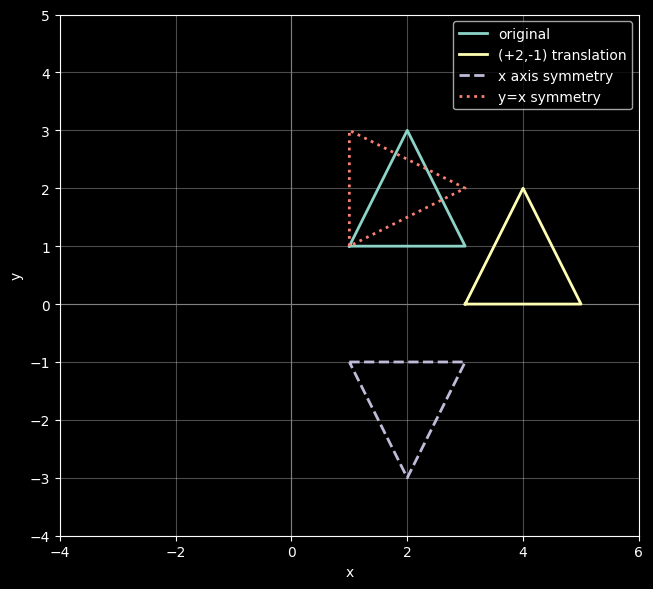

In [6]:
def plot_shape(shape, label, style='-'):
    plt.plot(shape[:, 0], shape[:, 1], style, lw=2, label=label)

plt.figure(figsize=(7, 6))
plt.axhline(0, color='gray', lw=0.8)
plt.axvline(0, color='gray', lw=0.8)
plot_shape(triangle, 'original')
plot_shape(moved, '(+2,-1) translation')
plot_shape(reflect_x(triangle), 'x axis symmetry', style='--')
plot_shape(reflect_yx(triangle), 'y=x symmetry', style=':')
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-4, 6); plt.ylim(-4, 5)
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


**np.array 형태 `(N, 2)`**: <br>
=> 각 행이 한 점 $(x,y)$ — 변환은 열 단위로 일괄 적용하면 편함
